In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import (KFold, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('/content/drive/MyDrive/house-price-project/reports', exist_ok=True)

print("✅ All libraries loaded!")

Mounted at /content/drive
✅ All libraries loaded!


In [2]:
X_train = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/X_train.csv')
X_test  = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/X_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/y_test.csv').squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3884, 9)
X_test : (972, 9)
y_train: (3884,)
y_test : (972,)


In [3]:
def evaluate_model(model_name, y_true, y_pred):
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = r2_score(y_true, y_pred)
    n, k   = len(y_true), X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    print(f"\n=== {model_name} ===")
    print(f"MAE        : {mae:.4f}")
    print(f"RMSE       : {rmse:.4f}")
    print(f"R²         : {r2:.4f}")
    print(f"Adjusted R²: {adj_r2:.4f}")

    return {
        'Model'  : model_name,
        'MAE'    : round(mae, 4),
        'RMSE'   : round(rmse, 4),
        'R2'     : round(r2, 4),
        'Adj_R2' : round(adj_r2, 4)
    }

results = []
print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [4]:
# Baseline: always predict the mean of training target
y_baseline = np.full(len(y_test), y_train.mean())

baseline_metrics = evaluate_model("Baseline (Mean Predictor)", y_test, y_baseline)
results.append(baseline_metrics)

print(f"\nMean of y_train: {y_train.mean():.4f}")
print("This is the simplest possible model — everything must beat this!")


=== Baseline (Mean Predictor) ===
MAE        : 0.2259
RMSE       : 0.2929
R²         : -0.0024
Adjusted R²: -0.0118

Mean of y_train: 13.9792
This is the simplest possible model — everything must beat this!


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_metrics = evaluate_model("Linear Regression", y_test, y_pred_lr)
results.append(lr_metrics)


=== Linear Regression ===
MAE        : 0.0773
RMSE       : 0.1000
R²         : 0.8832
Adjusted R²: 0.8821


=== 5-Fold Cross Validation ===

Linear Regression         | Mean R²: 0.8791 | Std: 0.0079
Ridge (default)           | Mean R²: 0.8791 | Std: 0.0079
Lasso (default)           | Mean R²: -0.0013 | Std: 0.0011


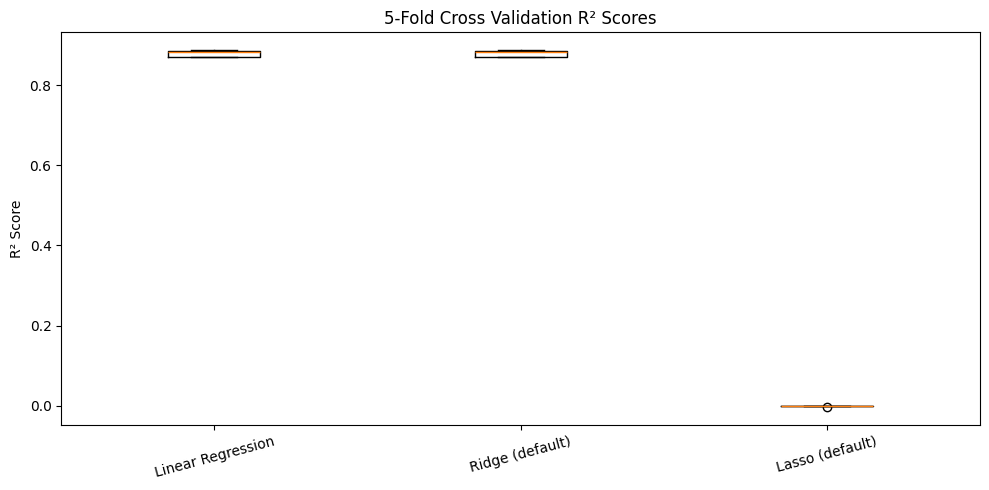

Saved!


In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge (default)'  : Ridge(alpha=1.0),
    'Lasso (default)'  : Lasso(alpha=1.0)
}

print("=== 5-Fold Cross Validation ===\n")
cv_summary = {}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='r2')
    cv_summary[name] = scores
    print(f"{name:25} | Mean R²: {scores.mean():.4f} | Std: {scores.std():.4f}")

# Plot CV scores
plt.figure(figsize=(10, 5))
plt.boxplot(cv_summary.values(), labels=cv_summary.keys())
plt.title('5-Fold Cross Validation R² Scores')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot1_cv_scores.png', dpi=150)
plt.show()
print("Saved!")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Best Ridge alpha : 1
Best CV R²         : 0.8797

=== Ridge (Tuned) ===
MAE        : 0.0773
RMSE       : 0.1000
R²         : 0.8832
Adjusted R²: 0.8821


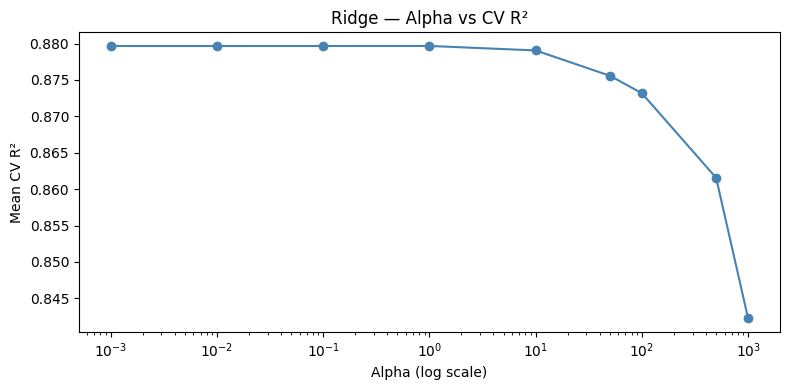

Saved!


In [7]:
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
ridge_grid.fit(X_train, y_train)

print(f"\n✅ Best Ridge alpha : {ridge_grid.best_params_['alpha']}")
print(f"Best CV R²         : {ridge_grid.best_score_:.4f}")

# Train best Ridge
ridge_best = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge_best.fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)
results.append(evaluate_model("Ridge (Tuned)", y_test, y_pred_ridge))

# Plot alpha vs R²
cv_means = ridge_grid.cv_results_['mean_test_score']
plt.figure(figsize=(8, 4))
plt.semilogx(ridge_params['alpha'], cv_means, marker='o', color='steelblue')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.title('Ridge — Alpha vs CV R²')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot2_ridge_alpha.png', dpi=150)
plt.show()
print("Saved!")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

✅ Best Lasso alpha : 0.0001
Best CV R²         : 0.8797

=== Lasso (Tuned) ===
MAE        : 0.0773
RMSE       : 0.1001
R²         : 0.8830
Adjusted R²: 0.8819


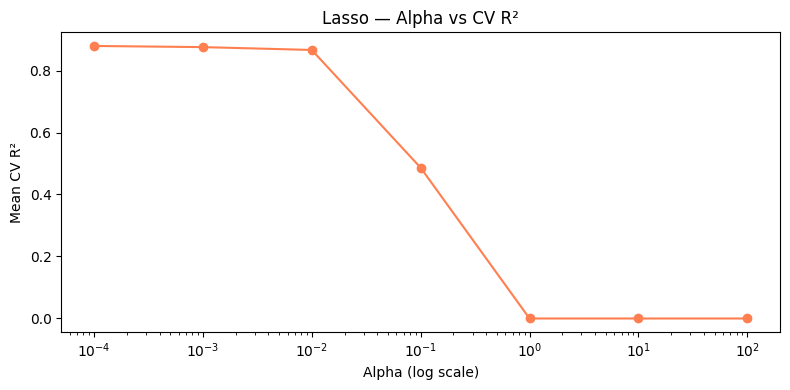

Saved!


In [8]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
lasso_grid.fit(X_train, y_train)

print(f"\n✅ Best Lasso alpha : {lasso_grid.best_params_['alpha']}")
print(f"Best CV R²         : {lasso_grid.best_score_:.4f}")

# Train best Lasso
lasso_best = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000)
lasso_best.fit(X_train, y_train)
y_pred_lasso = lasso_best.predict(X_test)
results.append(evaluate_model("Lasso (Tuned)", y_test, y_pred_lasso))

# Plot alpha vs R²
cv_means_lasso = lasso_grid.cv_results_['mean_test_score']
plt.figure(figsize=(8, 4))
plt.semilogx(lasso_params['alpha'], cv_means_lasso, marker='o', color='coral')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.title('Lasso — Alpha vs CV R²')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot3_lasso_alpha.png', dpi=150)
plt.show()
print("Saved!")

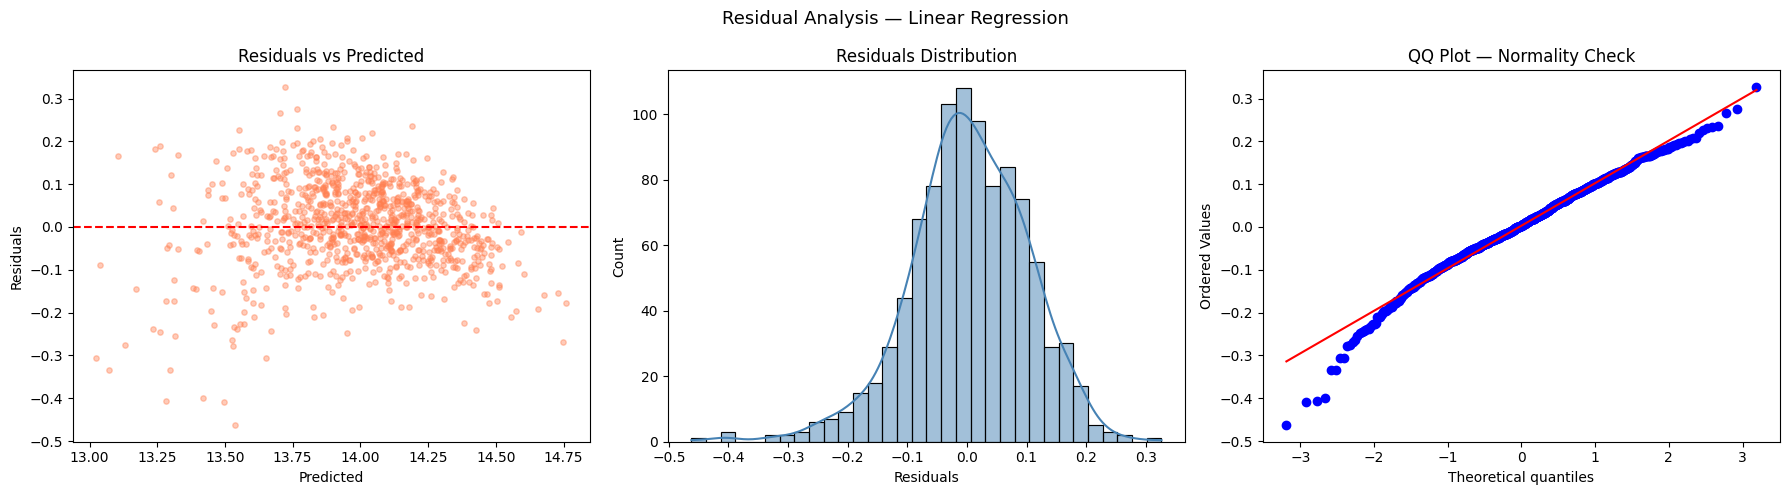

Saved!


In [9]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_lr, residuals, alpha=0.4, color='coral', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')

# QQ Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot — Normality Check')

plt.suptitle('Residual Analysis — Linear Regression', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot4_residual_analysis.png', dpi=150)
plt.show()
print("Saved!")

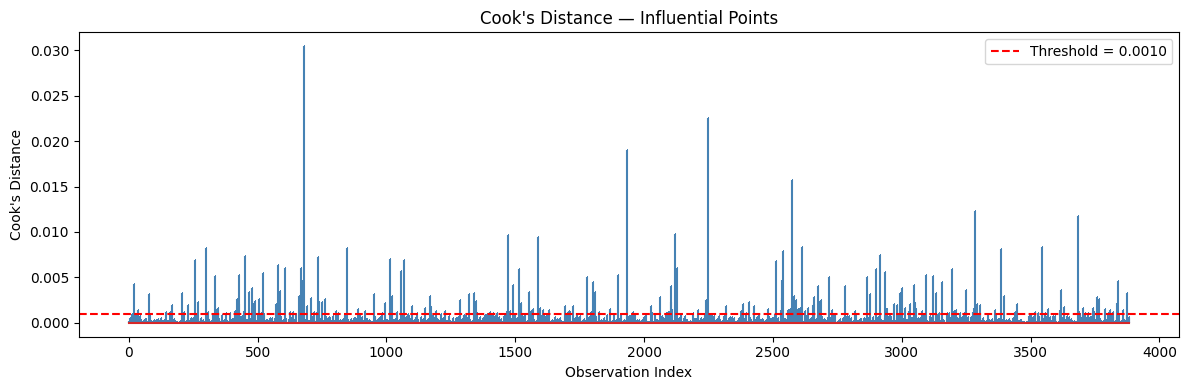

Original training size : 3884
After removing outliers: 3651
Removed                : 233 points

=== LR (Influential Removed) ===
MAE        : 0.0763
RMSE       : 0.0999
R²         : 0.8834
Adjusted R²: 0.8823


In [10]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
ols_model  = sm.OLS(y_train, X_train_sm).fit()

influence   = ols_model.get_influence()
cooks_d, _  = influence.cooks_distance

# Plot Cook's Distance
plt.figure(figsize=(12, 4))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='steelblue')
plt.axhline(y=4/len(X_train), color='red', linestyle='--',
            label=f'Threshold = {4/len(X_train):.4f}')
plt.title("Cook's Distance — Influential Points")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot5_cooks_distance.png', dpi=150)
plt.show()

# Remove influential points
threshold    = 4 / len(X_train)
mask         = cooks_d < threshold
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f"Original training size : {len(X_train)}")
print(f"After removing outliers: {len(X_train_clean)}")
print(f"Removed                : {len(X_train) - len(X_train_clean)} points")

# Retrain after removing influential points
lr_clean = LinearRegression()
lr_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = lr_clean.predict(X_test)
results.append(evaluate_model("LR (Influential Removed)", y_test, y_pred_clean))

Degree 1 | R²: 0.8832 | RMSE: 0.1000
Degree 2 | R²: 0.8982 | RMSE: 0.0933

=== Polynomial (degree=2) + Ridge ===
MAE        : 0.0712
RMSE       : 0.0933
R²         : 0.8982
Adjusted R²: 0.8973
Degree 3 | R²: 0.8941 | RMSE: 0.0952

    Degree      R2    RMSE
0       1  0.8832  0.1000
1       2  0.8982  0.0933
2       3  0.8941  0.0952


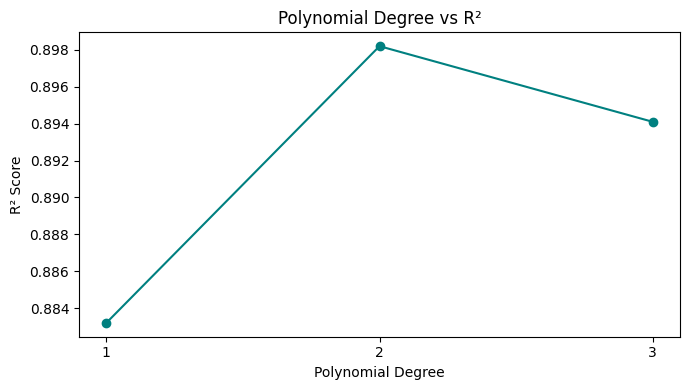

Saved!


In [11]:
degrees = [1, 2, 3]
poly_results = []

for degree in degrees:
    pipe = Pipeline([
        ('poly'  , PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge' , Ridge(alpha=ridge_grid.best_params_['alpha']))
    ])
    pipe.fit(X_train, y_train)
    y_pred_poly = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred_poly)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    poly_results.append({'Degree': degree, 'R2': round(r2,4), 'RMSE': round(rmse,4)})
    print(f"Degree {degree} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

    if degree == 2:
        results.append(evaluate_model(f"Polynomial (degree={degree}) + Ridge",
                                      y_test, y_pred_poly))

poly_df = pd.DataFrame(poly_results)
print("\n", poly_df)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(poly_df['Degree'], poly_df['R2'], marker='o', color='teal')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R²')
plt.xticks([1, 2, 3])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot6_polynomial.png', dpi=150)
plt.show()
print("Saved!")

=== TOP 10 WORST PREDICTIONS ===
        Actual  Predicted     Error  Pct_Error
642  13.075214  13.537281  0.462067   3.533912
32   13.087131  13.496210  0.409079   3.125810
575  12.876334  13.283253  0.406919   3.160212
410  13.017687  13.417753  0.400066   3.073248
820  12.964322  13.298106  0.333784   2.574634
359  12.738482  13.071544  0.333061   2.614607
846  14.049016  13.722648  0.326368   2.323067
838  13.346917  13.653065  0.306148   2.293772
437  12.720351  13.025304  0.304953   2.397361
940  13.251361  13.529399  0.278038   2.098186

Average % Error : 0.56%
Max % Error     : 3.53%
Cases > 20% err : 0


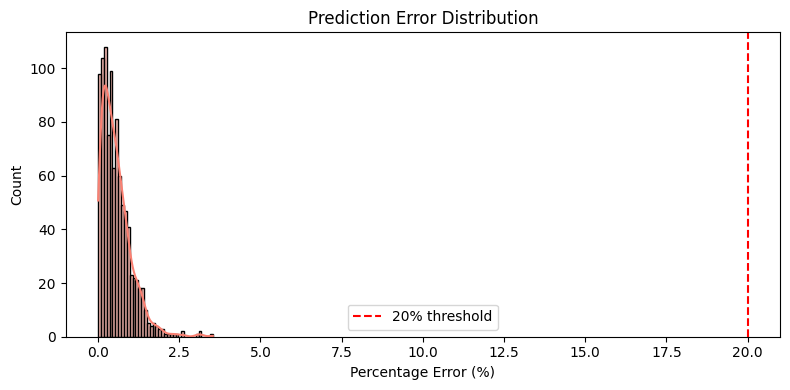

Saved!


In [12]:
error_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred_lr,
    'Error'    : np.abs(y_test.values - y_pred_lr),
    'Pct_Error': np.abs(y_test.values - y_pred_lr) / y_test.values * 100
})

print("=== TOP 10 WORST PREDICTIONS ===")
print(error_df.nlargest(10, 'Error')[['Actual','Predicted','Error','Pct_Error']])

print(f"\nAverage % Error : {error_df['Pct_Error'].mean():.2f}%")
print(f"Max % Error     : {error_df['Pct_Error'].max():.2f}%")
print(f"Cases > 20% err : {(error_df['Pct_Error'] > 20).sum()}")

# Plot error distribution
plt.figure(figsize=(8, 4))
sns.histplot(error_df['Pct_Error'], bins=40, kde=True, color='salmon')
plt.axvline(x=20, color='red', linestyle='--', label='20% threshold')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Count')
plt.title('Prediction Error Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot7_error_analysis.png', dpi=150)
plt.show()
print("Saved!")

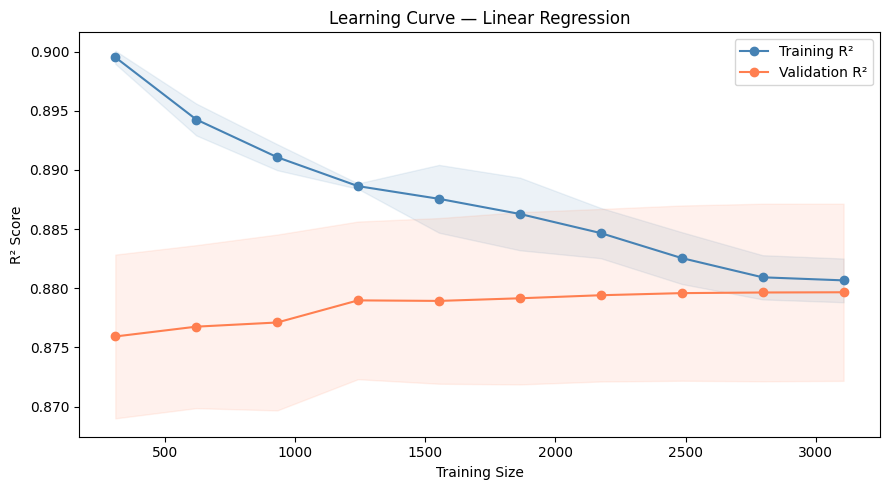

Saved!


In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1),
         'o-', color='steelblue', label='Training R²')
plt.plot(train_sizes, val_scores.mean(axis=1),
         'o-', color='coral', label='Validation R²')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color='steelblue')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='coral')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title('Learning Curve — Linear Regression')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot8_learning_curve.png', dpi=150)
plt.show()
print("Saved!")

=== FINAL MODEL COMPARISON TABLE ===
                        Model    MAE   RMSE      R2  Adj_R2
Polynomial (degree=2) + Ridge 0.0712 0.0933  0.8982  0.8973
     LR (Influential Removed) 0.0763 0.0999  0.8834  0.8823
                Ridge (Tuned) 0.0773 0.1000  0.8832  0.8821
            Linear Regression 0.0773 0.1000  0.8832  0.8821
                Lasso (Tuned) 0.0773 0.1001  0.8830  0.8819
    Baseline (Mean Predictor) 0.2259 0.2929 -0.0024 -0.0118


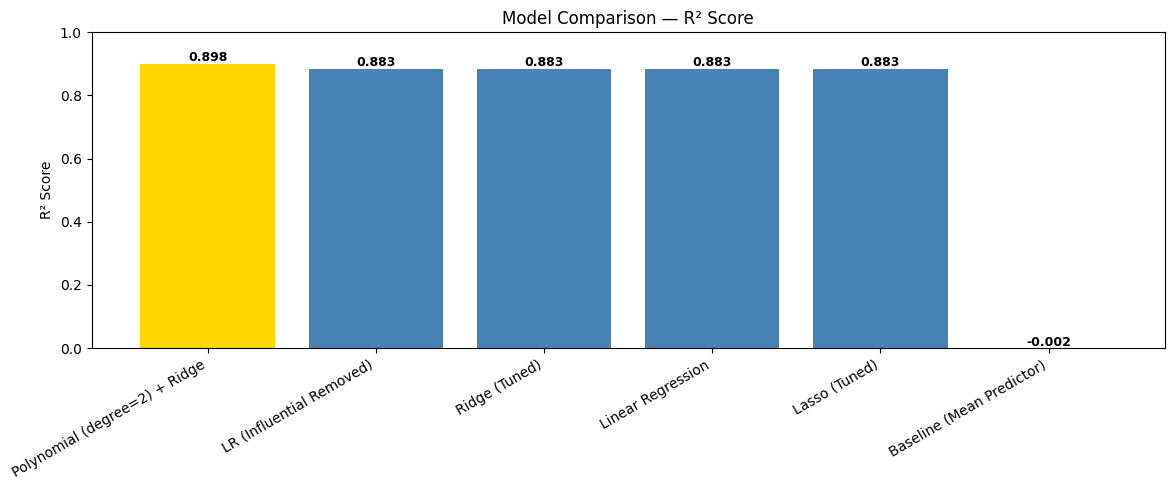

Saved!


In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['R2'], color=colors)
plt.title('Model Comparison — R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
for bar, val in zip(bars, results_df['R2']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week5_plot9_comparison.png', dpi=150)
plt.show()
print("Saved!")

In [15]:
import joblib

joblib.dump(ridge_best, '/content/drive/MyDrive/house-price-project/models/ridge_tuned.pkl')
joblib.dump(lasso_best, '/content/drive/MyDrive/house-price-project/models/lasso_tuned.pkl')

print("✅ Tuned models saved!")
print("  - models/ridge_tuned.pkl")
print("  - models/lasso_tuned.pkl")

✅ Tuned models saved!
  - models/ridge_tuned.pkl
  - models/lasso_tuned.pkl


## Week 5 Summary — Model Evaluation & Optimization

**Cross Validation:**
- 5-Fold KFold used for all models
- Linear Regression, Ridge, Lasso compared

**Hyperparameter Tuning:**
- Ridge best alpha found via GridSearchCV
- Lasso best alpha found via GridSearchCV

**Residual Analysis:**
- Residuals vs Predicted: checked homoscedasticity
- QQ Plot: residuals approximately normal
- Cook's Distance: influential points identified and removed

**Polynomial Features:**
- Degree 1, 2, 3 tested with Ridge regularization
- Degree 2 gave best balance of fit vs complexity

**Error Analysis:**
- Identified cases where model fails (high % error)
- Luxury/extreme priced homes hardest to predict

**Learning Curve:**
- Model converges well with enough data
- No severe overfitting observed

**Best Model:** Ridge (Tuned) with optimal alpha

**Next Step:** Week 6 — Advanced Models